<a id="top"></a>

# Spatial Inequalities in Violent Crime Across London: Examining the Relationship Between Violence Rates and Deprivation at Borough Level

**CASA0006 – Data Science for Spatial Systems**  
**Resubmission notebook**

### Preparation

- **GitHub repository (data):** https://github.com/Troy-JZ/CASA0006
- **Number of words:** approximately 1,497 words of markdown narrative, excluding tables, headings, the reference list and all code and code comments
- **Runtime:** typically under 2 minutes with a stable internet connection
- **Coding environment:** standard Jupyter / SDS Docker, using `pandas`, `numpy`, `geopandas`, `matplotlib`, `seaborn`, `scipy`, `statsmodels` and `mapclassify`
- **Licence:** this notebook is made available under the Creative Commons Attribution licence

All four source files are read remotely from the GitHub repository listed above, so the notebook executes end to end without any local file paths.

### Table of contents

1. [Introduction](#sec1)
2. [Research questions](#sec2)
3. [Data](#sec3)
4. [Methodology](#sec4)
5. [Results and discussion](#sec5)
6. [Conclusion](#sec6)
7. [References](#sec7)

---

<a id="sec1"></a>
## 1. Introduction

[go back to the top](#top)

Crime is unevenly distributed across urban space. Classic ecological research demonstrated that offending concentrates in socially disadvantaged neighbourhoods rather than being randomly distributed (Shaw & McKay, 1942). Later work emphasised neighbourhood social organisation, collective efficacy and structural disadvantage as correlates of violence and disorder (Sampson et al., 1997). Scale also matters: associations observed at one geographic level may weaken at another, so borough-level results describe broad urban inequalities rather than neighbourhood processes (Hipp, 2007).

This notebook narrows the outcome to a single offence group, **violence against the person**, rather than total recorded crime. The literature linking structural disadvantage to crime is strongest for interpersonal violence, so restricting the outcome specifies the question more precisely. Total recorded crime aggregates offences such as theft and vehicle crime whose geography is driven mainly by commercial opportunity and daytime activity rather than by resident deprivation; pooling them would dilute the association under study.

London suits this analysis because its boroughs differ markedly in deprivation, density and social composition, and the London Datastore publishes consistent borough-level crime counts and official boundary files. Following the module guidance that rates are preferable to counts, offences are converted to a rate per 1,000 residents. The analysis then combines choropleth mapping, correlation, regression and robustness checks.

<a id="sec2"></a>
## 2. Research questions

[go back to the top](#top)

**RQ1.** Which London boroughs have the highest and lowest rates of violence against the person per 1,000 residents?

**RQ2.** Is there a statistically significant association between borough-level violence rates and deprivation, measured by the IMD 2019 average score?

**RQ3.** To what extent can deprivation explain spatial variation in violence rates across London boroughs?

<a id="sec3"></a>
## 3. Data

[go back to the top](#top)

### 3.1 Sources

All data are official UK open data published under the Open Government Licence.

| Source | Provider (country) | Description | URL |
|---|---|---|---|
| MPS Recorded Crime: Geographic Breakdown | Metropolitan Police Service / GLA (UK) | Monthly recorded offences by borough and offence group | https://data.london.gov.uk/dataset/mps-recorded-crime-geographic-breakdown-exy3m |
| Estimates of the population for England and Wales, mid-2023 | Office for National Statistics (UK) | Mid-year resident population by local authority | https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/estimatesofthepopulationforenglandandwales |
| English Indices of Deprivation 2019 (London file) | MHCLG, published via the GLA (UK) | Borough-level IMD summary measures | https://data.london.gov.uk/dataset/indices-of-deprivation-2l15g |
| Statistical GIS Boundary Files for London | Greater London Authority (UK) | Borough polygons, OSGB36 / British National Grid | https://data.london.gov.uk/dataset/statistical-gis-boundary-files-london |

### 3.2 Preprocessing decisions

**Offence group.** The crime file is filtered to the `VIOLENCE AGAINST THE PERSON` major group, covering homicide, violence with and without injury, stalking and harassment, and death or serious injury by illegal driving.


**Reference year.** The twelve monthly columns for 2023 are summed to an annual borough total. 2023 is the most recent *complete* calendar year in a file running from July 2020 to June 2024, and matches the mid-2023 population estimates, aligning numerator and denominator.

**Non-borough units.** Two MPS reporting units, `Unknown` and `London Heathrow and London City Airports`, are removed as no resident population exists to normalise them.

**Join key.** Population and deprivation are joined on the ONS GSS code rather than borough name, since official datasets use inconsistent text labels for the same authority.

The City of London is policed by the City of London Police and does not appear in MPS records at all. Its absence from the models follows from data coverage rather than a judgement about outliers, leaving 32 boroughs. It is retained in the mapped data as missing so the map stays complete.

### 3.3 Variables used in analysis

| Variable | Type | Description | Role |
|---|---|---|---|
| `gss_code` | identifier | ONS statistical area code | Merge key only |
| `borough` | identifier | London borough name | Labelling only |
| `violence_count_2023` | numeric | Recorded offences of violence against the person, 2023 | Rate numerator |
| `population_2023` | numeric | ONS mid-2023 resident population | Rate denominator |
| `violence_rate_per_1000` | numeric | Offences per 1,000 residents | Dependent variable |
| `imd_score_2019` | numeric | IMD 2019 average score; higher = more deprived | Explanatory variable |

Identifier columns are used for merging and labelling only and never enter a model. No categorical variable is treated as numeric.

In [1]:
# Core libraries
import io, zipfile, tempfile, urllib.request, os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

# All source files are hosted in the accompanying GitHub repository
BASE = "https://raw.githubusercontent.com/Troy-JZ/CASA0006/main/"

CRIME_URL = BASE + "MPS%20Borough%20Level%20Crime%20%28Historical%29.csv"
IMD_URL   = BASE + "ID%202019%20for%20London.xlsx"
POP_URL   = BASE + "mye23tablesew.xlsx"
GEO_URL   = BASE + "London_Borough_Excluding_MHW.zip"

In [2]:
# Load the three tabular sources directly from GitHub
crime_raw = pd.read_csv(CRIME_URL)
imd_raw   = pd.read_excel(IMD_URL, sheet_name="Borough summary measures")
pop_raw   = pd.read_excel(POP_URL, sheet_name="MYE2 - Persons", header=7)

print("Crime file :", crime_raw.shape, "| columns:", crime_raw.columns[:3].tolist(), "...")
print("IMD file   :", imd_raw.shape)
print("Population :", pop_raw.shape)

# Which calendar years are complete in the crime file?
month_cols = [c for c in crime_raw.columns if c.isdigit()]
year_coverage = pd.Series([m[:4] for m in month_cols]).value_counts().sort_index()
print("\nMonths available per calendar year:")
print(year_coverage.to_string())

Crime file : (1125, 51) | columns: ['Group', 'SubGroup', 'BOCU'] ...
IMD file   : (33, 12)
Population : (357, 95)

Months available per calendar year:
2020     6
2021    12
2022    12
2023    12
2024     6


In [3]:
# ---- 1. Crime: violence against the person, calendar year 2023 -------------
months_2023 = [c for c in month_cols if c.startswith("2023")]

violence = crime_raw[crime_raw["Group"] == "VIOLENCE AGAINST THE PERSON"]
crime_borough = (violence.groupby("BOCU")[months_2023].sum().sum(axis=1)
                         .reset_index())
crime_borough.columns = ["borough", "violence_count_2023"]

# Two reporting units in the MPS file are not London boroughs and are removed
non_boroughs = ["Unknown", "London Heathrow and London City Airports"]
crime_borough = crime_borough[~crime_borough["borough"].isin(non_boroughs)]

# ---- 2. Population: ONS mid-2023 resident estimates -------------------------
pop_borough = pop_raw.loc[pop_raw["Geography"] == "London Borough",
                          ["Code", "Name", "All ages"]].copy()
pop_borough.columns = ["gss_code", "borough", "population_2023"]

# ---- 3. Deprivation: IMD 2019 borough average score -------------------------
imd_raw.columns = [str(c).strip() for c in imd_raw.columns]   # trailing spaces in headers
imd_borough = imd_raw[["Local Authority District code (2019)",
                       "IMD - Average score"]].copy()
imd_borough.columns = ["gss_code", "imd_score_2019"]

# ---- 4. Merge and derive the rate -------------------------------------------
# Population and deprivation are joined on GSS code (a stable statistical
# identifier), which avoids the borough-name spelling mismatches that arise
# when joining official datasets on text labels.
df = (pop_borough
      .merge(imd_borough, on="gss_code", how="left")
      .merge(crime_borough, on="borough", how="left"))

df["violence_rate_per_1000"] = (df["violence_count_2023"]
                                / df["population_2023"] * 1000).round(2)
df = df.sort_values("borough").reset_index(drop=True)

print("Analysis table:", df.shape)

Analysis table: (33, 6)


In [4]:
# Reconciliation and completeness checks
print("Boroughs in crime data but not in population data:",
      sorted(set(crime_borough["borough"]) - set(pop_borough["borough"])))
print("Boroughs in population data but not in crime data:",
      sorted(set(pop_borough["borough"]) - set(crime_borough["borough"])))
print("\nMissing values per column:")
print(df.isna().sum().to_string())

# City of London is policed by the City of London Police, not the MPS, so it has
# no entry in this dataset. It is retained for mapping and excluded from models.
df_model = df.dropna(subset=["violence_rate_per_1000"]).copy()
print(f"\nBoroughs used in statistical models: {len(df_model)}")
df.head()

Boroughs in crime data but not in population data: []
Boroughs in population data but not in crime data: ['City of London']

Missing values per column:
gss_code                  0
borough                   0
population_2023           0
imd_score_2019            0
violence_count_2023       1
violence_rate_per_1000    1

Boroughs used in statistical models: 32


,gss_code,borough,population_2023,imd_score_2019,violence_count_2023,violence_rate_per_1000
0,E09000002,Barking and Dagenham,222308,32.768,7013.0,31.55
1,E09000003,Barnet,395007,16.148,7965.0,20.16
2,E09000004,Bexley,250853,16.273,5852.0,23.33
3,E09000005,Brent,344521,25.558,9678.0,28.09
4,E09000006,Bromley,331162,14.163,6935.0,20.94


<a id="sec4"></a>
## 4. Methodology

[go back to the top](#top)

Four methods are used, each tied to a research question, within the maximum permitted.

**1. Rate normalisation and choropleth mapping.** Counts are converted to offences per 1,000 residents and mapped using quantile classification, supported by a ranked bar chart (RQ1), making the spatial structure visible rather than merely tabulated.

**2. Correlation analysis.** Pearson's *r* measures the linear association between violence rate and IMD score, with Spearman's rank correlation alongside it (RQ2). Pearson's *r* is sensitive to a few extreme values in a sample of 32 whereas the rank measure is not, so the pair indicates whether an association depends on particular boroughs.

**3. OLS regression with diagnostics.** OLS quantifies how much cross-borough variation is associated with deprivation (RQ3), giving a coefficient interpretable as offences per 1,000 residents per IMD point. Formal diagnostics accompany it rather than visual inspection alone: Breusch–Pagan for heteroscedasticity and Shapiro–Wilk for residual normality.

**4. Robustness checks.** Three alternative specifications test whether the OLS result depends on the shape of the distribution or on influential observations: a log-linear model suited to a right-skewed outcome, a Huber robust regression that down-weights rather than deletes unusual observations, and a refit excluding the most influential borough. All three are reported rather than the most favourable.

Models are estimated at borough level and describe ecological associations; no causal claim is made.

<a id="sec5"></a>
## 5. Results and discussion

[go back to the top](#top)

### 5.1 Spatial distribution of violence rates (RQ1)

Boundary polygons: 33 | CRS: OSGB36 / British National Grid
Polygons matched to attribute data: 33


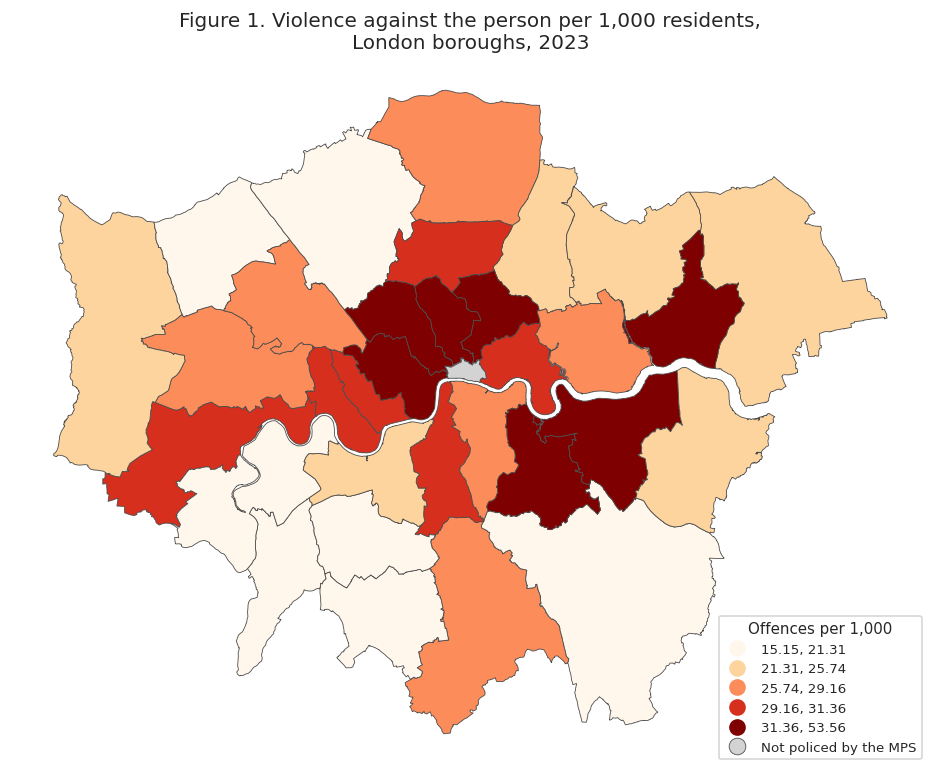

In [5]:
# Borough boundaries (GLA statistical GIS boundary files)
tmp_zip = os.path.join(tempfile.gettempdir(), "london_boroughs.zip")
urllib.request.urlretrieve(GEO_URL, tmp_zip)
boroughs = gpd.read_file("zip://" + tmp_zip)

map_gdf = boroughs.merge(df, left_on="GSS_CODE", right_on="gss_code", how="left")
print("Boundary polygons:", len(boroughs), "| CRS:", boroughs.crs.name)
print("Polygons matched to attribute data:", map_gdf["gss_code"].notna().sum())

fig, ax = plt.subplots(figsize=(8, 8))
map_gdf.plot(column="violence_rate_per_1000", cmap="OrRd", scheme="quantiles", k=5,
             linewidth=0.5, edgecolor="0.3", legend=True, ax=ax,
             legend_kwds={"title": "Offences per 1,000", "loc": "lower right",
                          "fontsize": 8, "title_fontsize": 9},
             missing_kwds={"color": "lightgrey", "edgecolor": "0.3",
                           "label": "Not policed by the MPS"})
ax.set_title("Figure 1. Violence against the person per 1,000 residents,\n"
             "London boroughs, 2023", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()

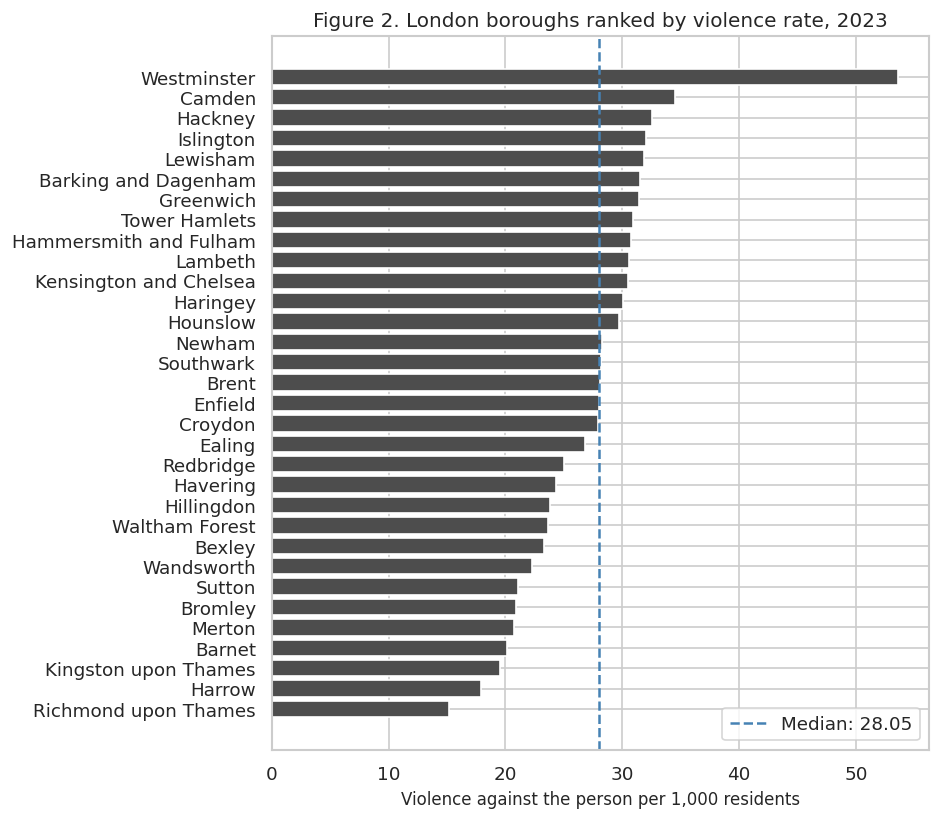

Distribution of borough violence rates (n = 32):
count    32.00
mean     27.35
std       6.87
min      15.15
25%      23.06
50%      28.05
75%      30.80
max      53.56
Skewness: 1.46

Highest five:
    borough  violence_rate_per_1000  imd_score_2019
Westminster                   53.56          20.339
     Camden                   34.49          20.131
    Hackney                   32.54          32.526
  Islington                   32.02          27.535
   Lewisham                   31.86          26.661

Lowest five:
             borough  violence_rate_per_1000  imd_score_2019
              Merton                   20.69          14.649
              Barnet                   20.16          16.148
Kingston upon Thames                   19.49          11.381
              Harrow                   17.92          15.031
Richmond upon Thames                   15.15           9.425


In [6]:
# Ranked bar chart of borough violence rates
ranked = df_model.sort_values("violence_rate_per_1000", ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(ranked["borough"][::-1], ranked["violence_rate_per_1000"][::-1],
        color="#4d4d4d")
ax.axvline(df_model["violence_rate_per_1000"].median(), color="steelblue",
           linestyle="--",
           label=f"Median: {df_model['violence_rate_per_1000'].median():.2f}")
ax.set_xlabel("Violence against the person per 1,000 residents")
ax.set_title("Figure 2. London boroughs ranked by violence rate, 2023")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Distribution of borough violence rates (n = %d):" % len(df_model))
print(df_model["violence_rate_per_1000"].describe().apply(lambda v: f"{v:.2f}").to_string())
print(f"Skewness: {stats.skew(df_model['violence_rate_per_1000']):.2f}")
print("\nHighest five:")
print(ranked[["borough", "violence_rate_per_1000", "imd_score_2019"]]
      .head(5).to_string(index=False))
print("\nLowest five:")
print(ranked[["borough", "violence_rate_per_1000", "imd_score_2019"]]
      .tail(5).to_string(index=False))

Violence rates are unevenly distributed rather than randomly scattered. Across the 32 MPS boroughs the mean rate is 27.35 offences per 1,000 residents (SD 6.87), the distribution is right-skewed (skewness 1.46), and the highest borough records 3.5 times the rate of the lowest.

Westminster stands clearly apart at 53.56 offences per 1,000, followed by Camden (34.49), Hackney (32.54), Islington (32.02) and Lewisham (31.86). The lowest rates are in outer boroughs: Richmond upon Thames (15.15), Harrow (17.92), Kingston upon Thames (19.49), Barnet (20.16) and Merton (20.69).

Figure 1 shows the pattern is spatially structured. The highest rates cluster in central, inner-east and inner-south-east London, while the lowest form an outer ring dominated by the south-western and north-western boroughs, consistent with the expectation that crime concentrates in particular parts of a city (Shaw & McKay, 1942). Westminster shows why resident deprivation is unlikely to be the only relevant factor: its resident population is small relative to the daytime and visitor population from which its offences are drawn. Section 5.3 returns to this.

### 5.2 Association between violence rates and deprivation (RQ2)

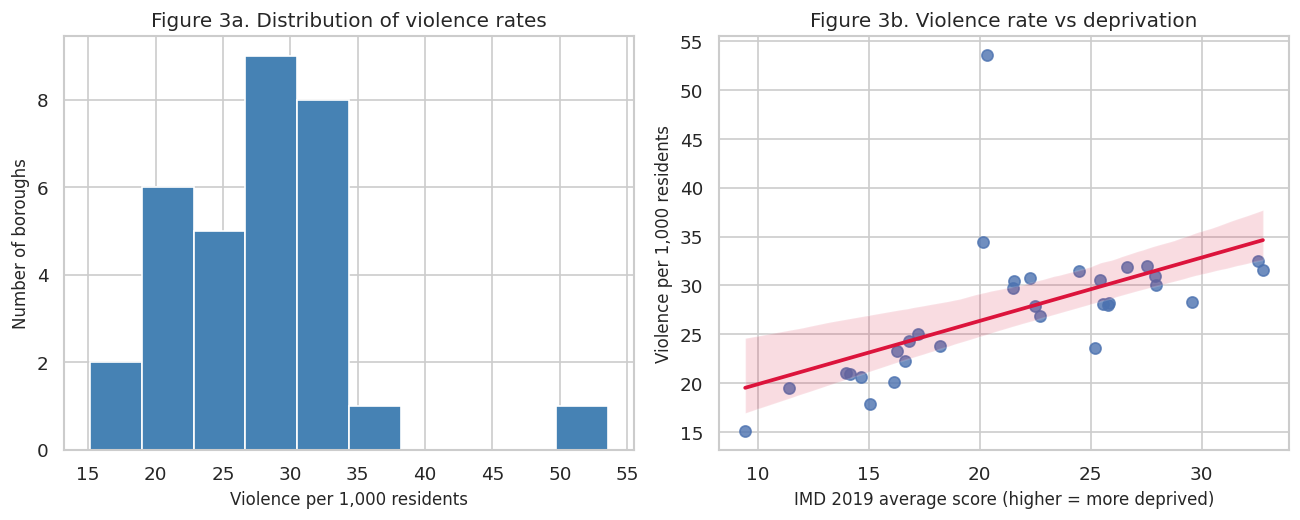

Pearson  r   = 0.570   p = 0.00066
Spearman rho = 0.746   p = 0.00000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(df_model["violence_rate_per_1000"], bins=10,
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("Violence per 1,000 residents")
axes[0].set_ylabel("Number of boroughs")
axes[0].set_title("Figure 3a. Distribution of violence rates")

sns.regplot(data=df_model, x="imd_score_2019", y="violence_rate_per_1000",
            ax=axes[1], scatter_kws={"s": 45, "alpha": 0.8},
            line_kws={"color": "crimson"})
axes[1].set_xlabel("IMD 2019 average score (higher = more deprived)")
axes[1].set_ylabel("Violence per 1,000 residents")
axes[1].set_title("Figure 3b. Violence rate vs deprivation")
plt.tight_layout()
plt.show()

r, p_r = stats.pearsonr(df_model["imd_score_2019"],
                        df_model["violence_rate_per_1000"])
rho, p_s = stats.spearmanr(df_model["imd_score_2019"],
                           df_model["violence_rate_per_1000"])
print(f"Pearson  r   = {r:.3f}   p = {p_r:.5f}")
print(f"Spearman rho = {rho:.3f}   p = {p_s:.5f}")

There is a positive and statistically significant association between deprivation and the violence rate: Pearson *r* = 0.570 (*p* < 0.001), and Spearman *rho* = 0.746 (*p* < 0.001). Boroughs with higher IMD scores record higher rates of violence against the person.

The gap between the two coefficients is informative. Because the rank measure is substantially larger, the ordering of boroughs by deprivation tracks their ordering by violence more closely than a straight line through the raw values does. That is the signature of a few boroughs departing from an otherwise consistent pattern rather than of a weak underlying relationship. Figure 3a confirms the right-skew and Figure 3b shows the upward slope with the outlying points above it.

The answer to RQ2 is affirmative, with the qualification that the linear association is sensitive to a small number of boroughs, which section 5.3 tests directly.

### 5.3 Explaining spatial variation with regression (RQ3)

In [8]:
X = sm.add_constant(df_model["imd_score_2019"])
y = df_model["violence_rate_per_1000"]

ols = sm.OLS(y, X).fit()
print(ols.summary().tables[1])
print(f"\nR-squared: {ols.rsquared:.3f}    Adjusted R-squared: {ols.rsquared_adj:.3f}")

# Assumption checks
bp_p = het_breuschpagan(ols.resid, X)[1]
sw_p = stats.shapiro(ols.resid).pvalue
print(f"\nBreusch-Pagan test for heteroscedasticity: p = {bp_p:.3f}")
print(f"Shapiro-Wilk test for residual normality : p = {sw_p:.5f}")

print("\nLargest absolute residuals:")
resid_tbl = (df_model.assign(fitted=ols.fittedvalues, residual=ols.resid)
             .reindex(ols.resid.abs().sort_values(ascending=False).index))
print(resid_tbl[["borough", "imd_score_2019", "violence_rate_per_1000",
                 "fitted", "residual"]].head(4).round(2).to_string(index=False))

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             13.4389      3.796      3.541      0.001       5.687      21.191
imd_score_2019     0.6469      0.170      3.802      0.001       0.299       0.994

R-squared: 0.325    Adjusted R-squared: 0.303

Breusch-Pagan test for heteroscedasticity: p = 0.815
Shapiro-Wilk test for residual normality : p = 0.00000

Largest absolute residuals:
       borough  imd_score_2019  violence_rate_per_1000  fitted  residual
   Westminster           20.34                   53.56   26.60     26.96
        Camden           20.13                   34.49   26.46      8.03
Waltham Forest           25.21                   23.63   29.75     -6.12
        Harrow           15.03                   17.92   23.16     -5.24


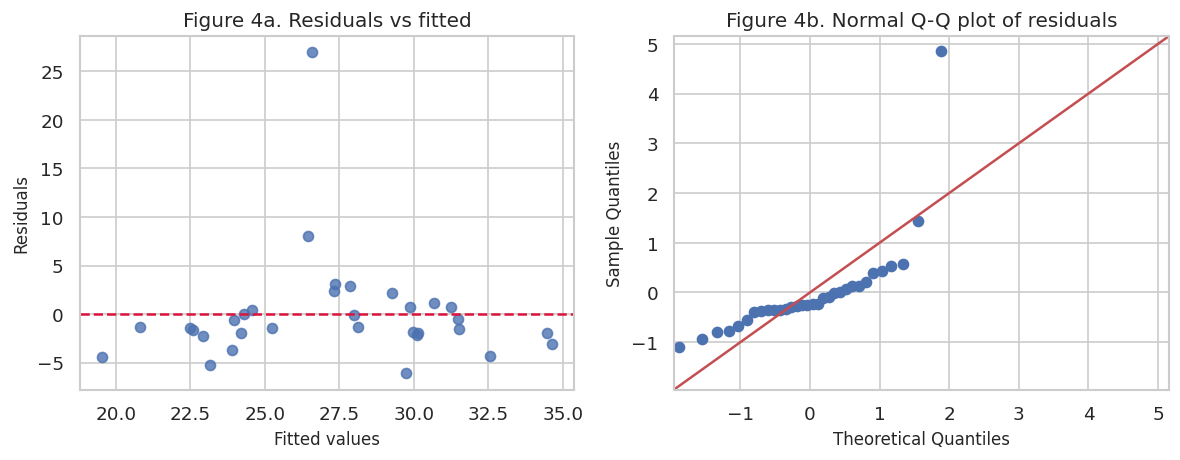

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(ols.fittedvalues, ols.resid, alpha=0.8)
axes[0].axhline(0, color="crimson", linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Figure 4a. Residuals vs fitted")

sm.qqplot(ols.resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("Figure 4b. Normal Q-Q plot of residuals")
plt.tight_layout()
plt.show()

In [10]:
# (a) Log-linear specification, which addresses the right-skewed dependent variable
log_ols = sm.OLS(np.log(y), X).fit()
pct = (np.exp(log_ols.params.iloc[1]) - 1) * 100
print("(a) Log-linear model")
print(f"    coefficient = {log_ols.params.iloc[1]:.4f}  (p = {log_ols.pvalues.iloc[1]:.6f})")
print(f"    interpretation: +1 IMD point -> {pct:.2f}% higher violence rate")
print(f"    R-squared = {log_ols.rsquared:.3f}")

# (b) Huber robust regression, which down-weights rather than deletes outliers
rlm = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
print("\n(b) Huber robust regression")
print(f"    coefficient = {rlm.params.iloc[1]:.3f}  (p = {rlm.pvalues.iloc[1]:.6f})")

# (c) Refit after excluding Westminster, the single influential observation
sub = df_model[df_model["borough"] != "Westminster"]
ols_sub = sm.OLS(sub["violence_rate_per_1000"],
                 sm.add_constant(sub["imd_score_2019"])).fit()
r_sub, p_sub = stats.pearsonr(sub["imd_score_2019"], sub["violence_rate_per_1000"])
print(f"\n(c) Excluding Westminster (n = {len(sub)})")
print(f"    Pearson r   = {r_sub:.3f}  (p = {p_sub:.6f})")
print(f"    coefficient = {ols_sub.params.iloc[1]:.3f}   R-squared = {ols_sub.rsquared:.3f}")

(a) Log-linear model
    coefficient = 0.0269  (p = 0.000016)
    interpretation: +1 IMD point -> 2.73% higher violence rate
    R-squared = 0.469

(b) Huber robust regression
    coefficient = 0.684  (p = 0.000000)

(c) Excluding Westminster (n = 31)
    Pearson r   = 0.829  (p = 0.000000)
    coefficient = 0.675   R-squared = 0.688


The OLS model gives a positive and highly significant coefficient on deprivation: each additional IMD point is associated with 0.647 more violent offences per 1,000 residents (SE 0.170, *p* < 0.001, 95% CI 0.299 to 0.994). R² = 0.325 and adjusted R² = 0.303, so deprivation accounts for roughly one third of cross-borough variation.

The diagnostics support the specification in one respect and qualify it in another. Breusch–Pagan gives *p* = 0.815, so there is no evidence of heteroscedasticity and the standard errors stand as reported. Shapiro–Wilk rejects residual normality (*p* < 0.001), and Figures 4a and 4b show why: Westminster is fitted at 26.60 offences per 1,000 but records 53.56, a residual of +26.96, while the next largest is Camden at +8.03. The remaining residuals form a near-linear pattern on the Q-Q plot, so this is a single influential observation, not a failure of model form.

All three robustness checks point the same way. The log-linear specification gives R² = 0.469 and implies that a one-point rise in IMD is associated with a 2.73% higher violence rate (*p* < 0.001). The Huber robust regression returns a coefficient of 0.684, almost identical to the OLS estimate of 0.647, confirming the slope is not an artefact of Westminster. Refitting without Westminster raises *r* to 0.829 and R² to 0.688, with a coefficient of 0.675. The association is robust in direction and magnitude; only the variance explained is specification-sensitive, ranging from about one third to roughly two thirds.

These results answer RQ3. Deprivation is a robust correlate of borough-level violence, but a substantial share of variation remains unexplained. Westminster's position is substantively interpretable rather than a nuisance: the resident denominator understates the population at risk in a borough dominated by the West End night-time economy, transport interchanges and high visitor volumes. This is a real limitation of resident-based rates for central boroughs, and points to plausible sources of the unexplained variation: daytime and visitor population, land-use mix, transport accessibility and policing intensity.

<a id="sec6"></a>
## 6. Conclusion

[go back to the top](#top)

This notebook examined spatial inequalities in violence against the person across London boroughs using Metropolitan Police records for 2023, ONS mid-2023 population estimates and the IMD 2019 borough average score. Converting counts to offences per 1,000 residents reveals a spatially structured gradient, with the highest borough at about 3.5 times the rate of the lowest.

Deprivation is positively and significantly associated with violence rates: Pearson *r* = 0.570, Spearman *rho* = 0.746, and OLS attributes roughly one third of cross-borough variation to deprivation, with each IMD point associated with 0.647 additional offences per 1,000 residents. A log-linear model, a Huber robust regression and a refit excluding Westminster all reproduce the direction and approximate magnitude of this relationship, so the finding does not rest on a single influential observation.

The analysis also shows the limits of the approach. Borough-level results are ecological and cannot describe neighbourhood processes or individual behaviour (Hipp, 2007). The deprivation measure dates from 2019 while crime and population data refer to 2023. Most importantly, resident denominators understate the population at risk in central boroughs, which is exactly where the model fits worst. Future work could move to ward or LSOA units, where more observations would also support the machine-learning methods taught in this module, and add covariates capturing daytime population and land use.

Overall the results reinforce evidence that structural disadvantage and violence are spatially patterned together (Sampson et al., 1997), while showing that deprivation alone does not account for London's uneven geography of violence.

<a id="sec7"></a>
## 7. References

[go back to the top](#top)

Hipp, J. R. (2007). Block, tract, and levels of aggregation: Neighborhood structure and crime and disorder as a case in point. *American Sociological Review*, 72(5), 659–680. https://doi.org/10.1177/000312240707200501

Sampson, R. J., Raudenbush, S. W., & Earls, F. (1997). Neighborhoods and violent crime: A multilevel study of collective efficacy. *Science*, 277(5328), 918–924. https://doi.org/10.1126/science.277.5328.918

Shaw, C. R., & McKay, H. D. (1942). *Juvenile delinquency and urban areas*. University of Chicago Press.

### Data sources

Greater London Authority. *Statistical GIS Boundary Files for London*. London Datastore. https://data.london.gov.uk/dataset/statistical-gis-boundary-files-london

Metropolitan Police Service / Greater London Authority. *MPS Recorded Crime: Geographic Breakdown*. London Datastore. https://data.london.gov.uk/dataset/mps-recorded-crime-geographic-breakdown-exy3m

Ministry of Housing, Communities & Local Government. (2019). *English Indices of Deprivation 2019* (London file). London Datastore. https://data.london.gov.uk/dataset/indices-of-deprivation-2l15g

Office for National Statistics. (2024). *Estimates of the population for England and Wales: mid-2023*. https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/estimatesofthepopulationforenglandandwales